# Gender Classification using Fingerprints

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
print(filename)  # As you can see, the filename contains useful information such as gender and finger type. 
# So we need to extract those words.

44__M_Left_little_finger_CR.BMP


In [3]:
dirname

'/kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Hard'

In [4]:
def extraction(img_path):  #We only need to extract gender
    filename = os.path.basename(img_path)
    gender = filename.split("__")[1].split("_")[0]
    return 0 if gender == 'M' else 1

In [5]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

2025-08-03 05:08:52.137145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754197732.362210      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754197732.426341      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
img_size=96

def load(path):
    print("Loading data from:", path)
    data = []

    for image in os.listdir(path):
        try:
            img_path = os.path.join(path, image)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img_resize = cv2.resize(img_array, (img_size, img_size))
            img_ready = img_resize.reshape(img_size, img_size, 1) / 255.0
            label = extraction(img_path)  
            data.append([label, img_ready])

        except Exception as e:
            print(f"Error: {e} -> {image}")
            continue

    return data

#We read the image, converted it to black and white, resized it, normalized it and added it to the list as a label-image.

In [7]:
Real_path = "/kaggle/input/socofing/socofing/SOCOFing/Real"
Easy_path = "/kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Easy"
Medium_path = "/kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Medium"
Hard_path = "/kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Hard"


Easy_data = load(Easy_path)
Medium_data = load(Medium_path)
Hard_data = load(Hard_path)
test = load(Real_path)

data = Easy_data + Medium_data + Hard_data

del Easy_data, Medium_data, Hard_data


Loading data from: /kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Easy
Loading data from: /kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Medium
Loading data from: /kaggle/input/socofing/socofing/SOCOFing/Altered/Altered-Hard
Loading data from: /kaggle/input/socofing/socofing/SOCOFing/Real


In [8]:
labels, train_data = zip(*data) 
labels = np.array(labels)
train_data = np.stack(train_data)  

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model= Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(96, 96, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation="relu"),
    Conv2D(512, (3,3), activation="relu"),
    Flatten(),
    Dropout(0.2),
    Dense(250, activation="relu"),
    Dense(1, activation="sigmoid")
    ])

#We created the neural network model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1754198042.533012      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [10]:
model.compile(optimizer="adam",loss="binary_crossentropy", metrics=["accuracy"])

In [11]:
history=model.fit(train_data,labels,epochs=20, batch_size=32, verbose=1)

Epoch 1/20


I0000 00:00:1754198052.487012      62 service.cc:148] XLA service 0x787068004080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754198052.487488      62 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1754198052.878516      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


  18/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6545 - loss: 0.6039 

I0000 00:00:1754198055.993318      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.7966 - loss: 0.4962
Epoch 2/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8102 - loss: 0.4478
Epoch 3/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8273 - loss: 0.4072
Epoch 4/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8786 - loss: 0.2951
Epoch 5/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9461 - loss: 0.1378
Epoch 6/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9752 - loss: 0.0696
Epoch 7/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9822 - loss: 0.0495
Epoch 8/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9867 - loss: 0.0383
Epoch 9/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9902 - loss: 0.0289
Epoch 10/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9900 - loss: 0.0298
Epoch 11/20
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9908 - loss: 0.0268
Epoch 12/20
1540/1540 ━━━━━━━

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │     4,608,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,529,505 (70.68 MB)

 Trainable params: 6,176,501 (23.56 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,353,004 (47.12 MB)

(0.0, 1.0)

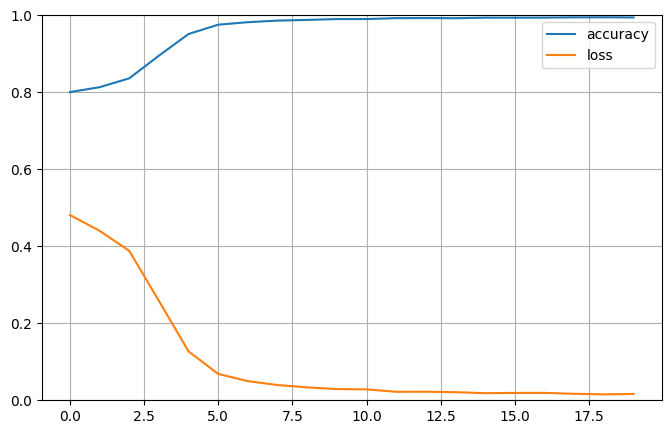

In [13]:
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize = (8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)

In [14]:
test_labels, test_data = zip(*test) 
test_labels = np.array(test_labels)
test_data = np.stack(test_data) 

In [15]:
model.evaluate(test_data, test_labels)  #we are testing our model

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9977 - loss: 0.0063


[0.006246584001928568, 0.9981666803359985]

### NOTE: This project has been developed as part of a course assignment. The original version was obtained from the following source: "https://amanxai.com/2020/08/02/gender-classification-model/". In accordance with the instructions, I studied the provided solution and then implemented my own approach to solve it independently.